# Simple LightGBM Model Development

This notebook follows one focused progression:

1. Validate `development_features.parquet`
2. Create the chronological training and validation sets
3. Train a raw-feature LightGBM baseline
4. Train a LightGBM model with engineered features
5. Compare both feature sets
6. Tune the selected model's classification threshold
7. Save the selected model and its metadata

> **Target meaning:** `is_attributed = 1` means the click led to an attributed app installation. It is not a confirmed fraud label.

## 1. Imports and project settings

In [1]:

from pathlib import Path
import json
import warnings

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "development_features.parquet"
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "is_attributed"
TIME_COLUMN = "click_time"
VALIDATION_START = pd.Timestamp("2017-11-07 14:30:00")
RANDOM_STATE = 42
# Final operational policy: prioritise recall while selecting the best
# available precision among thresholds that achieve at least 80% recall.
TARGET_RECALL = 0.80

RAW_FEATURES = ["ip", "app", "device", "os", "channel"]
CATEGORICAL_FEATURES = ["app", "device", "os", "channel"]
EXCLUDED_COLUMNS = {TARGET, TIME_COLUMN, "attributed_time"}

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset: {DATA_PATH}")

Project root: d:\Projects\Ad_Click_Fraud_Detection
Dataset: d:\Projects\Ad_Click_Fraud_Detection\data\processed\development_features.parquet


## 2. Load and validate the processed data

The checks below confirm the file structure, target, timestamps, feature values and chronological order before modelling.

In [2]:

if not DATA_PATH.exists():

    raise FileNotFoundError(f"Processed dataset not found: {DATA_PATH}")

df = pd.read_parquet(DATA_PATH)

required_columns = set(RAW_FEATURES + [TIME_COLUMN, TARGET])
missing_columns = sorted(required_columns - set(df.columns))

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

if not pd.api.types.is_datetime64_any_dtype(df[TIME_COLUMN]):
    df[TIME_COLUMN] = pd.to_datetime(df[TIME_COLUMN], errors="raise")

target_values = set(df[TARGET].dropna().unique())
if not target_values.issubset({0, 1}) or df[TARGET].isna().any():
    raise ValueError(f"{TARGET} must contain only 0 and 1 with no missing values.")

if not df[TIME_COLUMN].is_monotonic_increasing:
    raise ValueError(f"{TIME_COLUMN} is not sorted chronologically.")

if not df[TIME_COLUMN].min() < VALIDATION_START <= df[TIME_COLUMN].max():
    raise ValueError("VALIDATION_START is outside the dataset's time range.")


model_candidates = [column for column in df.columns if column not in EXCLUDED_COLUMNS]
non_numeric = [column for column in model_candidates if not pd.api.types.is_numeric_dtype(df[column])]
if non_numeric:
    raise TypeError(f"Non-numeric model columns found: {non_numeric}")


missing_feature_values = int(df[model_candidates].isna().sum().sum())
infinite_feature_values = int(np.isinf(df[model_candidates].to_numpy()).sum())
if missing_feature_values or infinite_feature_values:
    raise ValueError(
        f"Invalid feature values — missing: {missing_feature_values:,}, "
        f"infinite: {infinite_feature_values:,}"
    )

validation_summary = pd.Series({
    "rows": len(df),
    "columns": df.shape[1],
    "start_time": df[TIME_COLUMN].min(),
    "end_time": df[TIME_COLUMN].max(),
    "attributed_clicks": int(df[TARGET].sum()),
    "attribution_rate_percent": df[TARGET].mean() * 100,
})

print("All dataset validations passed.")
display(validation_summary.to_frame("value"))

All dataset validations passed.


,value
rows,6397036
columns,18
start_time,2017-11-07 13:00:00
end_time,2017-11-07 14:59:59
attributed_clicks,15775
attribution_rate_percent,0.246599


## 3. Define raw and engineered feature sets

In [3]:
# Feature engineering columns 
ENGINEERED_FEATURES = [
    column for column in df.columns
    if column not in EXCLUDED_COLUMNS
]

ADDED_ENGINEERED_FEATURES = [
    column for column in ENGINEERED_FEATURES
    if column not in RAW_FEATURES
]

if not ADDED_ENGINEERED_FEATURES:
    raise ValueError("No engineered features were found in the processed dataset.")

print(f"Raw model ({len(RAW_FEATURES)} features): {RAW_FEATURES}")
print(f"\nAdded engineered features ({len(ADDED_ENGINEERED_FEATURES)}):")
for feature in ADDED_ENGINEERED_FEATURES:
    print(f"  - {feature}")
print(f"\nEngineered model total: {len(ENGINEERED_FEATURES)} features")

Raw model (5 features): ['ip', 'app', 'device', 'os', 'channel']

Added engineered features (11):
  - click_day
  - click_hour
  - click_minute
  - click_second
  - click_day_of_week
  - previous_ip_clicks
  - previous_ip_app_clicks
  - previous_ip_channel_clicks
  - seconds_since_previous_ip_click
  - seconds_since_previous_ip_app_click
  - seconds_since_previous_ip_channel_click

Engineered model total: 16 features


## 4. Chronological split

Clicks before 14:30 form the training set. Clicks from 14:30 onward form the validation set. No random split is used.

In [4]:

train_mask = df[TIME_COLUMN] < VALIDATION_START
validation_mask = ~train_mask


y_train = df.loc[train_mask, TARGET]
y_validation = df.loc[validation_mask, TARGET]

split_summary = pd.DataFrame(
    {
    "rows": [int(train_mask.sum()), int(validation_mask.sum())],
    "attributed_clicks": [int(y_train.sum()), int(y_validation.sum())],
    "attribution_rate_percent": [y_train.mean() * 100, y_validation.mean() * 100],
    }, 
    index=["Training", "Validation"]
)

display(split_summary.style.format({
    "rows": "{:,.0f}",
    "attributed_clicks": "{:,.0f}",
    "attribution_rate_percent": "{:.6f}%",
}))

,rows,attributed_clicks,attribution_rate_percent
Training,"4,866,118","12,689",0.260762%
Validation,"1,530,918","3,086",0.201578%


## 5. Reusable training and evaluation functions

PR-AUC is the primary comparison metric because attributed clicks are very rare. Accuracy is included for completeness but is not used alone to choose the model.

In [5]:
# Function for Lightgbm model

def build_model():
    return lgb.LGBMClassifier(
        objective="binary",
        n_estimators=1200,
        learning_rate=0.03,
        num_leaves=63,
        min_child_samples=50,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )


# Metrics evaluation function
def evaluate_predictions(y_true, probabilities, threshold=0.50):
    predictions = (probabilities >= threshold).astype(np.uint8)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()

    return {
        "pr_auc": average_precision_score(y_true, probabilities),
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
    }


# Train model
def train_model(model_name, feature_names):
    X_train = df.loc[train_mask, feature_names]
    X_validation = df.loc[validation_mask, feature_names]
    categorical = [name for name in CATEGORICAL_FEATURES if name in feature_names]

    model = build_model()
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_validation, y_validation)],
        eval_metric="average_precision",
        categorical_feature=categorical,
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, first_metric_only=True),
            lgb.log_evaluation(period=50),
        ],
    )

    probabilities = model.predict_proba(
        X_validation,
        num_iteration=model.best_iteration_,
    )[:, 1]
    
    metrics = evaluate_predictions(y_validation, probabilities)
    metrics["model"] = model_name
    metrics["feature_count"] = len(feature_names)

    del X_train, X_validation
    return model, probabilities, metrics

## 6. Train the raw-feature baseline

In [6]:
raw_model, raw_probabilities, raw_metrics = train_model(
    model_name="Raw LightGBM",
    feature_names=RAW_FEATURES,
)

display(pd.DataFrame([raw_metrics]).set_index("model"))
print(f"Best iteration: {raw_model.best_iteration_}")

Training until validation scores don't improve for 50 rounds
[50]	valid_0's average_precision: 0.271925	valid_0's binary_logloss: 0.206192
[100]	valid_0's average_precision: 0.312233	valid_0's binary_logloss: 0.131206
[150]	valid_0's average_precision: 0.407706	valid_0's binary_logloss: 0.114203
[200]	valid_0's average_precision: 0.450974	valid_0's binary_logloss: 0.107942
[250]	valid_0's average_precision: 0.462074	valid_0's binary_logloss: 0.10295
[300]	valid_0's average_precision: 0.464263	valid_0's binary_logloss: 0.0993077
[350]	valid_0's average_precision: 0.463635	valid_0's binary_logloss: 0.0963744
Early stopping, best iteration is:
[325]	valid_0's average_precision: 0.464747	valid_0's binary_logloss: 0.0977754
Evaluated only: average_precision


,pr_auc,threshold,accuracy,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives,feature_count
model,,,,,,,,,,,
Raw LightGBM,0.464747,0.500000,0.978983,0.080908,0.909916,0.148603,1495934,31898,278,2808,5


Best iteration: 325


## 7. Train the engineered-feature model

In [7]:
engineered_model, engineered_probabilities, engineered_metrics = train_model(
    model_name="Engineered LightGBM",
    feature_names=ENGINEERED_FEATURES,
)

display(pd.DataFrame([engineered_metrics]).set_index("model"))
print(f"Best iteration: {engineered_model.best_iteration_}")

Training until validation scores don't improve for 50 rounds
[50]	valid_0's average_precision: 0.386006	valid_0's binary_logloss: 0.202388
[100]	valid_0's average_precision: 0.416479	valid_0's binary_logloss: 0.12372
[150]	valid_0's average_precision: 0.468291	valid_0's binary_logloss: 0.102213
[200]	valid_0's average_precision: 0.531376	valid_0's binary_logloss: 0.0909626
[250]	valid_0's average_precision: 0.541953	valid_0's binary_logloss: 0.0805579
[300]	valid_0's average_precision: 0.544975	valid_0's binary_logloss: 0.0736997
[350]	valid_0's average_precision: 0.545897	valid_0's binary_logloss: 0.0673995
[400]	valid_0's average_precision: 0.546893	valid_0's binary_logloss: 0.0631196
[450]	valid_0's average_precision: 0.547272	valid_0's binary_logloss: 0.0594469
[500]	valid_0's average_precision: 0.548727	valid_0's binary_logloss: 0.0558864
Early stopping, best iteration is:
[494]	valid_0's average_precision: 0.549241	valid_0's binary_logloss: 0.0564117
Evaluated only: average_preci

,pr_auc,threshold,accuracy,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives,feature_count
model,,,,,,,,,,,
Engineered LightGBM,0.549241,0.500000,0.987315,0.126333,0.894686,0.221403,1508738,19094,325,2761,16


Best iteration: 494


## 8. Compare feature-set performance at the default threshold

In [8]:
comparison = (
    pd.DataFrame([raw_metrics, engineered_metrics])
    .set_index("model")
    .sort_values("pr_auc", ascending=False)
)

display(comparison.style.format({
    "pr_auc": "{:.6f}",
    "threshold": "{:.2f}",
    "accuracy": "{:.6f}",
    "precision": "{:.6f}",
    "recall": "{:.6f}",
    "f1": "{:.6f}",
    "feature_count": "{:,.0f}",
    "true_negatives": "{:,.0f}",
    "false_positives": "{:,.0f}",
    "false_negatives": "{:,.0f}",
    "true_positives": "{:,.0f}",
}))

selected_name = comparison.index[0]
if selected_name == "Engineered LightGBM":
    selected_model = engineered_model
    selected_probabilities = engineered_probabilities
    selected_features = ENGINEERED_FEATURES
else:
    selected_model = raw_model
    selected_probabilities = raw_probabilities
    selected_features = RAW_FEATURES

print(f"Selected by validation PR-AUC: {selected_name}")

,pr_auc,threshold,accuracy,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives,feature_count
model,,,,,,,,,,,
Engineered LightGBM,0.549241,0.50,0.987315,0.126333,0.894686,0.221403,"1,508,738","19,094",325,"2,761",16
Raw LightGBM,0.464747,0.50,0.978983,0.080908,0.909916,0.148603,"1,495,934","31,898",278,"2,808",5


Selected by validation PR-AUC: Engineered LightGBM


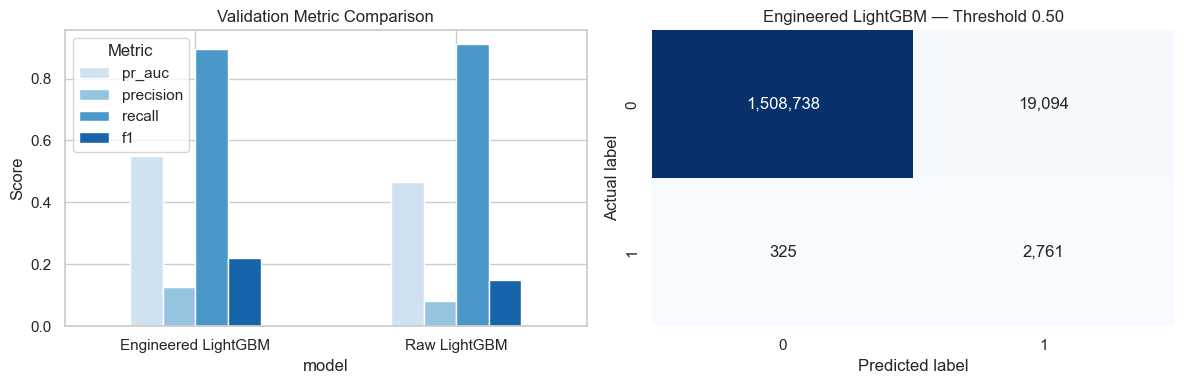

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
metric_names = ["pr_auc", "precision", "recall", "f1"]
comparison[metric_names].plot(kind="bar", ax=axes[0], rot=0, color=sns.color_palette("Blues", 4))
axes[0].set_title("Validation Metric Comparison")
axes[0].set_ylabel("Score")
axes[0].legend(title="Metric")

selected_default_predictions = (selected_probabilities >= 0.50).astype(np.uint8)
selected_default_cm = confusion_matrix(y_validation, selected_default_predictions, labels=[0, 1])
sns.heatmap(selected_default_cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=axes[1])
axes[1].set_title(f"{selected_name} — Threshold 0.50")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("Actual label")
plt.tight_layout()
plt.show()

## 9. Select the final operating threshold

Two thresholds are evaluated: maximum F1, and the highest-precision threshold that maintains at least 80% recall. The 80%-recall threshold is saved for deployment. PR-AUC does not change because it evaluates probability ranking rather than one classification threshold.

In [10]:
curve_precision, curve_recall, thresholds = precision_recall_curve(
    y_validation,
    selected_probabilities,
)
f1_values = (
    2 * curve_precision[:-1] * curve_recall[:-1]
    / (curve_precision[:-1] + curve_recall[:-1] + 1e-12)
)
best_index = int(np.argmax(f1_values))
selected_threshold = float(thresholds[best_index])

default_metrics = evaluate_predictions(y_validation, selected_probabilities, threshold=0.50)
tuned_metrics = evaluate_predictions(
    y_validation,
    selected_probabilities,
    threshold=selected_threshold,
)

threshold_comparison = pd.DataFrame(
    [default_metrics, tuned_metrics],
    index=["Default threshold", "Maximum-F1 threshold"],
)
display(threshold_comparison.style.format({
    "pr_auc": "{:.6f}",
    "threshold": "{:.6f}",
    "accuracy": "{:.6f}",
    "precision": "{:.6f}",
    "recall": "{:.6f}",
    "f1": "{:.6f}",
    "true_negatives": "{:,.0f}",
    "false_positives": "{:,.0f}",
    "false_negatives": "{:,.0f}",
    "true_positives": "{:,.0f}",
}))

,pr_auc,threshold,accuracy,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives
Default threshold,0.549241,0.500000,0.987315,0.126333,0.894686,0.221403,"1,508,738","19,094",325,"2,761"
Maximum-F1 threshold,0.549241,0.990447,0.998136,0.535980,0.559948,0.547702,"1,526,336","1,496","1,358","1,728"


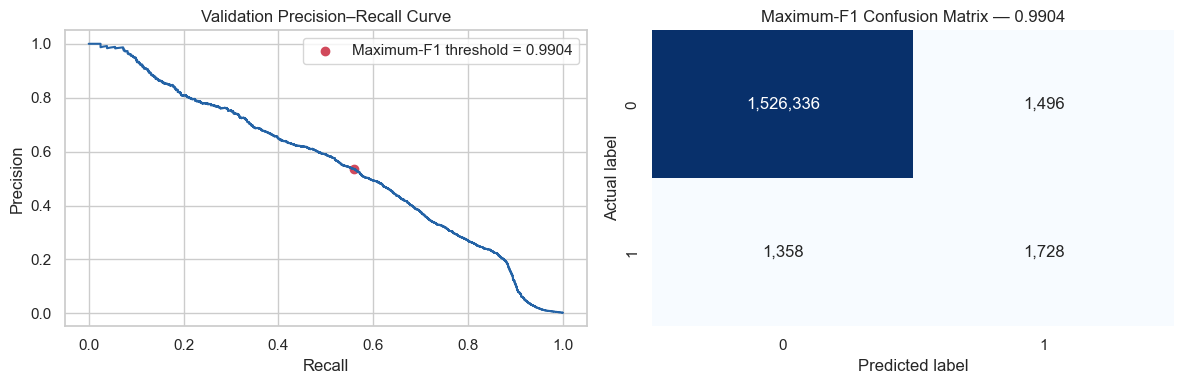

In [11]:
# Precision - Recall Curve : Validation

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(curve_recall, curve_precision, color="#2463A6")
axes[0].scatter(
    curve_recall[best_index],
    curve_precision[best_index],
    color="#D1495B",
    label=f"Maximum-F1 threshold = {selected_threshold:.4f}",
)
axes[0].set_title("Validation Precision–Recall Curve")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].legend()

tuned_predictions = (selected_probabilities >= selected_threshold).astype(np.uint8)
tuned_cm = confusion_matrix(y_validation, tuned_predictions, labels=[0, 1])
sns.heatmap(tuned_cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=axes[1])
axes[1].set_title(f"Maximum-F1 Confusion Matrix — {selected_threshold:.4f}")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("Actual label")
plt.tight_layout()
plt.show()

In [12]:
# Select the highest-precision threshold that still meets the recall policy.
valid_indexes = np.where(
    curve_recall[:-1] >= TARGET_RECALL
)[0]

if len(valid_indexes) == 0:
    raise ValueError(
        f"No threshold achieved {TARGET_RECALL:.0%} recall."
    )

# Among thresholds meeting the recall target,
# select the one with the highest precision.
best_index = valid_indexes[
    np.argmax(curve_precision[:-1][valid_indexes])
]

recall_threshold = float(thresholds[best_index])

recall_target_metrics = evaluate_predictions(
    y_validation,
    selected_probabilities,
    threshold=recall_threshold,
)

print(f"Target recall: {TARGET_RECALL:.0%}")
print(f"Selected threshold: {recall_threshold:.6f}")

display(
    pd.DataFrame(
        [recall_target_metrics],
        index=[f"Minimum {TARGET_RECALL:.0%} recall"],
    ).style.format({
        "pr_auc": "{:.6f}",
        "threshold": "{:.6f}",
        "accuracy": "{:.6f}",
        "precision": "{:.6f}",
        "recall": "{:.6f}",
        "f1": "{:.6f}",
        "true_negatives": "{:,.0f}",
        "false_positives": "{:,.0f}",
        "false_negatives": "{:,.0f}",
        "true_positives": "{:,.0f}",
    })
)

Target recall: 80%
Selected threshold: 0.954368


,pr_auc,threshold,accuracy,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives
Minimum 80% recall,0.549241,0.954368,0.995238,0.270072,0.800065,0.403827,"1,521,159","6,673",617,"2,469"


In [ ]:
# Comparison of separate target recalls

recall_targets = [0.70, 0.80, 0.85, 0.90]
recall_results = []

for target_recall in recall_targets:

    valid_indexes = np.where(
        curve_recall[:-1] >= target_recall
    )[0]

    if len(valid_indexes) == 0:
        continue

    best_index = valid_indexes[
        np.argmax(curve_precision[:-1][valid_indexes])
    ]

    threshold = float(thresholds[best_index])

    metrics = evaluate_predictions(
        y_validation,
        selected_probabilities,
        threshold=threshold,
    )

    metrics["target_recall"] = target_recall
    recall_results.append(metrics)

recall_comparison = pd.DataFrame(recall_results)

display(
    recall_comparison[
        [
            "target_recall",
            "threshold",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "false_positives",
            "false_negatives",
            "true_positives",
        ]
    ].style.format({
        "target_recall": "{:.0%}",
        "threshold": "{:.6f}",
        "accuracy": "{:.4%}",
        "precision": "{:.4%}",
        "recall": "{:.4%}",
        "f1": "{:.6f}",
        "false_positives": "{:,.0f}",
        "false_negatives": "{:,.0f}",
        "true_positives": "{:,.0f}",
    })
)

# Overall best is selected

,target_recall,threshold,accuracy,precision,recall,f1,false_positives,false_negatives,true_positives
0,70%,0.977153,99.7056%,37.6284%,70.0259%,0.489523,"3,582",925,"2,161"
1,80%,0.954368,99.5238%,27.0072%,80.0065%,0.403827,"6,673",617,"2,469"
2,85%,0.909222,99.3994%,23.1047%,85.0292%,0.363359,"8,733",462,"2,624"
3,90%,0.438279,98.4667%,10.7077%,90.0194%,0.191388,"23,166",308,"2,778"


## 10. Save the selected model and metadata

The metadata records the exact feature list, chronological split, selected threshold, validation results and software versions needed by the later Streamlit application.

In [14]:
MODEL_PATH = MODEL_DIR / "final_lightgbm_model.joblib"
METADATA_PATH = MODEL_DIR / "final_lightgbm_metadata.json"

metadata = {
    "model_name": selected_name,
    "model_type": "LightGBM LGBMClassifier",
    "target": TARGET,
    "positive_class_meaning": "Click led to an attributed app installation",
    "validation_start": VALIDATION_START.isoformat(),
    "selection_metric": "validation_pr_auc",
    "threshold_method": "highest_precision_at_minimum_80_percent_validation_recall",
    "decision_threshold": recall_threshold,
    "features": selected_features,
    "categorical_features": [
        name for name in CATEGORICAL_FEATURES if name in selected_features
    ],
    "best_iteration": int(selected_model.best_iteration_),
    "validation_metrics_default_threshold": default_metrics,
    "validation_metrics_maximum_f1_threshold": tuned_metrics,
    "validation_metrics_operational_threshold": recall_target_metrics,
    "library_versions": {
        "lightgbm": lgb.__version__,
        "pandas": pd.__version__,
        "numpy": np.__version__,
    },
}

joblib.dump(selected_model, MODEL_PATH)
with METADATA_PATH.open("w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)

print(f"Saved model: {MODEL_PATH}")
print(f"Saved metadata: {METADATA_PATH}")

Saved model: d:\Projects\Ad_Click_Fraud_Detection\models\final_lightgbm_model.joblib
Saved metadata: d:\Projects\Ad_Click_Fraud_Detection\models\final_lightgbm_metadata.json


## Final interpretation checklist

Before accepting the result, confirm that:

- the engineered model improves validation PR-AUC enough to justify the additional features;
- accuracy is interpreted alongside precision, recall and F1;
- the tuned threshold provides a sensible precision–recall trade-off;
- the model output is described as attribution probability, not confirmed fraud probability; and
- XGBoost is tested later only if a separate challenger is genuinely useful.